In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import linear_sum_assignment

rng = np.random.default_rng(42)

def lk_norm(X, k):
    """Distancia L_k al origen (punto de consulta), como en el paper. X: (..., d)"""
    return (np.abs(X) ** k).sum(axis=-1) ** (1.0 / k)

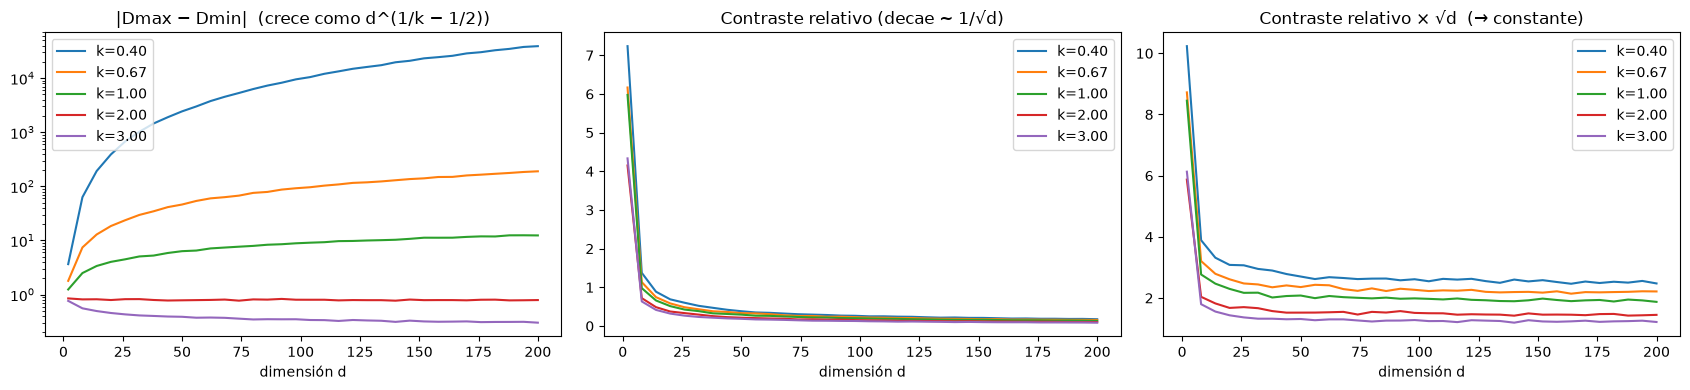

In [2]:
def experimento(d, k, N=10, trials=300):
    X = rng.random((trials, N, d))          # datos uniformes en (0,1)
    D = lk_norm(X, k)                       # (trials, N)
    dmax, dmin = D.max(1), D.min(1)
    return (dmax - dmin).mean(), ((dmax - dmin) / dmin).mean()

dims = np.arange(2, 201, 6)
ks = [0.4, 2/3, 1, 2, 3]

fig, ax = plt.subplots(1, 3, figsize=(17, 4))
for k in ks:
    res = np.array([experimento(d, k) for d in dims])
    ax[0].plot(dims, res[:, 0], label=f"k={k:.2f}")
    ax[1].plot(dims, res[:, 1], label=f"k={k:.2f}")
    ax[2].plot(dims, res[:, 1] * np.sqrt(dims), label=f"k={k:.2f}")

ax[0].set_title("|Dmax − Dmin|  (crece como d^(1/k − 1/2))"); ax[0].set_yscale("log")
ax[1].set_title("Contraste relativo (decae ~ 1/√d)")
ax[2].set_title("Contraste relativo × √d  (→ constante)")
for a in ax: a.set_xlabel("dimensión d"); a.legend()
plt.tight_layout(); plt.show()

In [3]:
def prob_U_menor_T(d, N=10, trials=1000):
    X = rng.random((trials, N, d))
    def rc(k):
        D = lk_norm(X, k)
        return (D.max(1) - D.min(1)) / D.min(1)
    U, T = rc(2), rc(1)          # U = contraste L2, T = contraste L1
    return (U < T).mean()

for d in [2, 3, 4, 10, 15, 20, 100]:
    print(f"d={d:>3}  P[U<T] = {prob_U_menor_T(d)*100:.1f}%")

d=  2  P[U<T] = 86.9%
d=  3  P[U<T] = 88.5%
d=  4  P[U<T] = 92.5%
d= 10  P[U<T] = 96.7%
d= 15  P[U<T] = 97.0%
d= 20  P[U<T] = 97.1%
d=100  P[U<T] = 97.9%


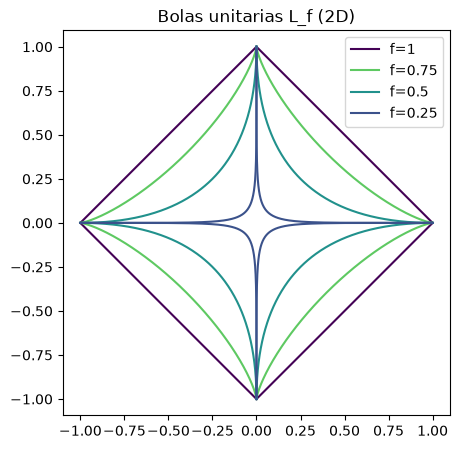

In [4]:
t = np.linspace(0, np.pi/2, 400)
plt.figure(figsize=(5, 5))
for f in [1, 0.75, 0.5, 0.25]:
    x, y = np.cos(t)**(2/f), np.sin(t)**(2/f)     # |x|^f + |y|^f = 1
    for sx, sy in [(1,1), (-1,1), (-1,-1), (1,-1)]:
        plt.plot(sx*x, sy*y, color=plt.cm.viridis(f), label=f"f={f}" if (sx,sy)==(1,1) else None)
plt.axis("equal"); plt.legend(); plt.title("Bolas unitarias L_f (2D)")
plt.show()

p=0.1  → 99.8%
p=0.3  → 99.9%
p=0.5  → 100.0%
p=1    → 100.0%
p=1.5  → 100.0%
p=2    → 75.8%
p=3    → 99.9%


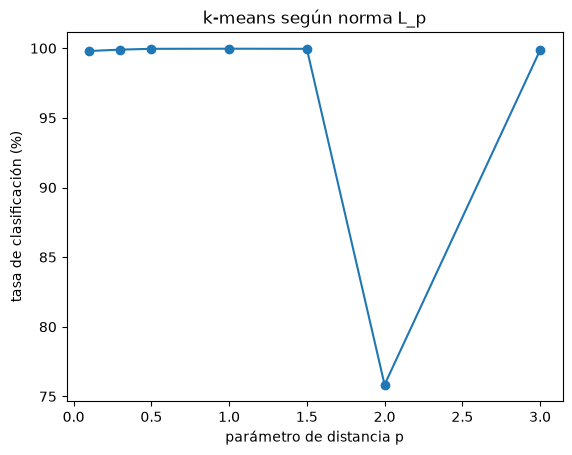

In [5]:
def make_data(n_per=2000, d=20, k=6):
    centers = rng.random((k, d)) * 10
    sig = rng.uniform(0.3, 3.0, size=(k, d))       # dispersión distinta por dimensión
    X = np.vstack([rng.normal(centers[i], sig[i], (n_per, d)) for i in range(k)])
    y = np.repeat(np.arange(k), n_per)
    return X, y

def kmeans_p(X, k, p, iters=40, seed=0):
    r = np.random.default_rng(seed)
    C = X[r.choice(len(X), k, replace=False)]
    for _ in range(iters):
        D = (np.abs(X[:, None, :] - C[None]) ** p).sum(2)   # distancia^p (monótona en la dist)
        lab = D.argmin(1)
        C = np.array([X[lab == j].mean(0) if (lab == j).any() else C[j] for j in range(k)])
    return lab

def clasif_rate(y, lab, k=6):
    conf = np.zeros((k, k), int)
    for a, b in zip(lab, y): conf[a, b] += 1
    r, c = linear_sum_assignment(-conf)                     # mejor emparejamiento cluster↔clase
    return conf[r, c].sum() / len(y)

X, y = make_data()
ps = [0.1, 0.3, 0.5, 1, 1.5, 2, 3]
rates = []
for p in ps:
    best = max(clasif_rate(y, kmeans_p(X, 6, p, seed=s)) for s in range(5))  # 5 inicializaciones
    rates.append(best * 100)
    print(f"p={p:<4} → {best*100:.1f}%")

plt.plot(ps, rates, "o-"); plt.xlabel("parámetro de distancia p")
plt.ylabel("tasa de clasificación (%)"); plt.title("k-means según norma L_p"); plt.show()

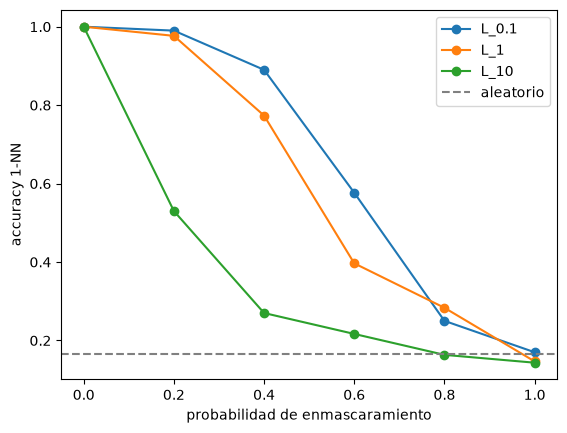

In [6]:
def accuracy_vecino(X, y, p, n_q=300):
    idx = rng.choice(len(X), n_q, replace=False)
    ok = 0
    for i in idx:
        d = (np.abs(X - X[i]) ** p).sum(1); d[i] = np.inf
        ok += y[d.argmin()] == y[i]
    return ok / n_q

Xs, ys = make_data(n_per=500)
mask_probs = np.linspace(0, 1, 6)
for p in [0.1, 1, 10]:
    accs = []
    for pc in mask_probs:
        Xn = Xs.copy()
        m = rng.random(Xn.shape) < pc                       # entradas reemplazadas por ruido
        Xn[m] = rng.uniform(Xs.min(), Xs.max(), m.sum())
        accs.append(accuracy_vecino(Xn, ys, p))
    plt.plot(mask_probs, accs, "o-", label=f"L_{p}")
plt.axhline(1/6, color="gray", ls="--", label="aleatorio")
plt.xlabel("probabilidad de enmascaramiento"); plt.ylabel("accuracy 1-NN"); plt.legend(); plt.show()